# 🤖 Faz 7: Makine Öğrenmesi — Çoklu Model Karşılaştırma

**Problem:** Customer Lifetime Value (CLV) Tahmini — Regresyon  
**Veri:** Gold tablosu (`delta_lake/gold/customer_features`)  
**Target:** `future_spending`

## Eğitilecek Modeller (5 adet)

| # | Model | Tip | Güçlü Yanı |
|---|-------|-----|------------|
| 1 | Linear Regression | Doğrusal | Yorumlanabilir, hızlı baseline |
| 2 | Decision Tree | Ağaç tabanlı | Doğrusal olmayan ilişkileri yakalar |
| 3 | Random Forest | Ensemble | Overfitting'e dayanıklı, robust |
| 4 | Gradient Boosted Trees | Ensemble | Genelde en iyi performans |
| 5 | Generalized Linear Regression | İstatistiksel | Dağılım varsayımları |

## Değerlendirme Metrikleri

- **RMSE** (Root Mean Squared Error) — Hatanın karekökü, büyük hatalara cezayı arttırır
- **MAE** (Mean Absolute Error) — Ortalama mutlak hata, outlier'lara dayanıklı
- **R² Score** — Modelin varyansı açıklama oranı (1.0 = mükemmel)

## MLflow Entegrasyonu

Her model deneyi otomatik olarak MLflow'a kaydedilir:
- Parametreler (model hyperparameter'ları)
- Metrikler (RMSE, MAE, R²)
- Modelin kendisi (artifact)
- Feature Importance (varsa)

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from src.spark_session import get_spark_session

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Görsel stili
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# MLflow
import mlflow
import mlflow.spark

# Spark ML
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import (
    LinearRegression, DecisionTreeRegressor, RandomForestRegressor,
    GBTRegressor, GeneralizedLinearRegression
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col, log1p, expm1

# Spark Session
spark = get_spark_session(
    app_name="ML-Models",
    master="local[2]",
    driver_memory="4g"
)

# MLflow tracking URI - Docker container'daki MLflow server
mlflow.set_tracking_uri("http://localhost:5001")

print(f"✅ Spark {spark.version}")
print(f"✅ MLflow tracking: {mlflow.get_tracking_uri()}")

26/05/11 10:46:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✅ Spark 3.5.1
✅ MLflow tracking: http://localhost:5001


In [2]:
EXPERIMENT_NAME = "customer_lifetime_value_prediction"

# Experiment yoksa oluştur, varsa kullan
mlflow.set_experiment(EXPERIMENT_NAME)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print(f"✅ MLflow Experiment: {EXPERIMENT_NAME}")
print(f"   ID: {experiment.experiment_id}")
print(f"   URL: http://localhost:5001/#/experiments/{experiment.experiment_id}")

✅ MLflow Experiment: customer_lifetime_value_prediction
   ID: 651823729774552597
   URL: http://localhost:5001/#/experiments/651823729774552597


## 1. Veriyi Yükle ve Hazırla

Gold tablosundan müşteri seviyesinde feature tablosunu yüklüyoruz.

In [3]:
GOLD_PATH = os.path.abspath("../delta_lake/gold/customer_features")

df = spark.read.format("delta").load(GOLD_PATH)

print(f"📊 Gold tablo: {df.count():,} müşteri × {len(df.columns)} sütun\n")
print("📋 Şema:")
df.printSchema()

print("\n📊 İlk 5 satır:")
df.show(5)

26/05/11 10:46:29 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


📊 Gold tablo: 317 müşteri × 12 sütun

📋 Şema:
root
 |-- kullanici_ID: long (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- frequency: long (nullable = true)
 |-- monetary: double (nullable = true)
 |-- avg_basket_value: double (nullable = true)
 |-- avg_days_between_purchases: double (nullable = true)
 |-- unique_products: long (nullable = true)
 |-- cancellation_count: long (nullable = true)
 |-- active_months: long (nullable = true)
 |-- most_active_hour: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- future_spending: double (nullable = true)


📊 İlk 5 satır:
+------------+------------+---------+-----------------+------------------+--------------------------+---------------+------------------+-------------+----------------+--------------+------------------+
|kullanici_ID|recency_days|frequency|         monetary|  avg_basket_value|avg_days_between_purchases|unique_products|cancellation_count|active_months|most_active_hour|       country|   fu

📊 Target (future_spending) istatistikleri:
count      317.000000
mean       779.685905
std       1728.801967
min          1.300000
25%        219.410000
50%        366.730000
75%        699.930000
max      19809.900000
Name: future_spending, dtype: float64


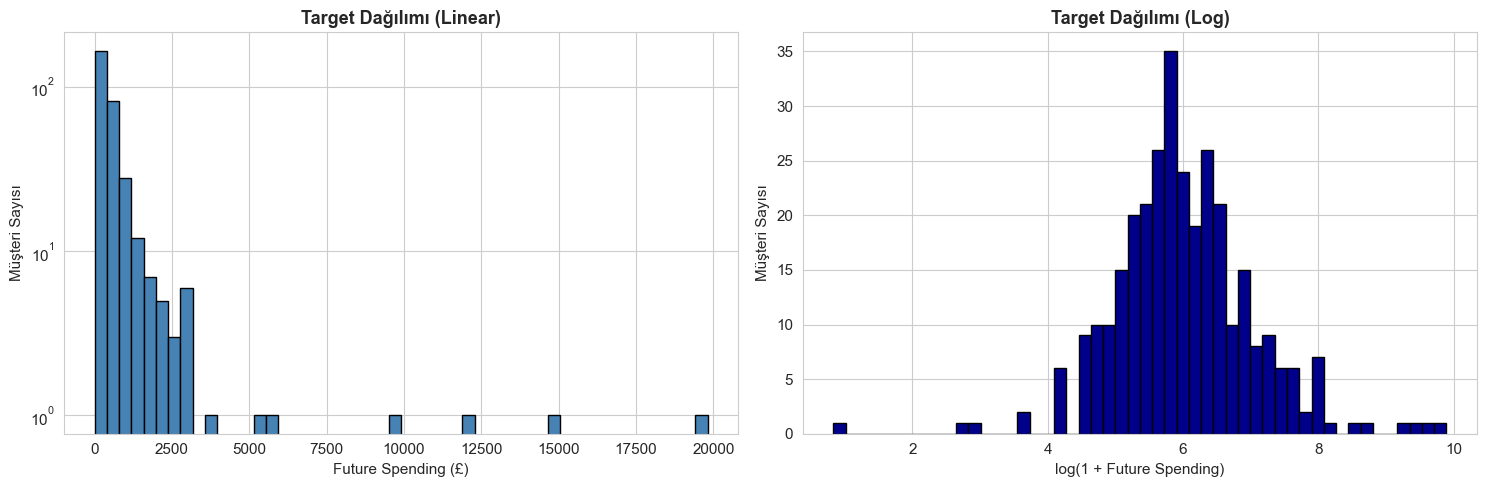


💡 Skewness (çarpıklık): 7.54
   |Skewness| > 1 → Çok çarpık, log dönüşüm yardımcı olabilir.


In [4]:
df_pd = df.toPandas()

# Target istatistikleri
print("📊 Target (future_spending) istatistikleri:")
print(df_pd['future_spending'].describe())

# Görsel
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_pd['future_spending'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Future Spending (£)')
axes[0].set_ylabel('Müşteri Sayısı')
axes[0].set_title('Target Dağılımı (Linear)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')

axes[1].hist(np.log1p(df_pd['future_spending']), bins=50, color='darkblue', edgecolor='black')
axes[1].set_xlabel('log(1 + Future Spending)')
axes[1].set_ylabel('Müşteri Sayısı')
axes[1].set_title('Target Dağılımı (Log)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/07_target_dist_before.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n💡 Skewness (çarpıklık): {df_pd['future_spending'].skew():.2f}")
print("   |Skewness| > 1 → Çok çarpık, log dönüşüm yardımcı olabilir.")

In [5]:
from pyspark.sql.functions import expr

print(f"📊 Başlangıç: {df.count():,} müşteri")

# 1. future_spending > 0 olanları al
df_clean = df.filter(col("future_spending") > 0)
print(f"   ↳ future_spending > 0: {df_clean.count():,} müşteri")

# 2. Sadece üst %1'lik kısmı outlier kabul et (çok agresif değil!)
upper_target = df_clean.approxQuantile("future_spending", [0.99], 0.01)[0]
print(f"   ↳ Target 99 persantil: £{upper_target:.2f}")

df_clean = df_clean.filter(col("future_spending") <= upper_target)
print(f"   ↳ Target outlier sonrası: {df_clean.count():,} müşteri")

# 3. Monetary için de hafif temizlik (sadece üst %1)
upper_monetary = df_clean.approxQuantile("monetary", [0.99], 0.01)[0]
df_clean = df_clean.filter(col("monetary") <= upper_monetary)
print(f"   ↳ Monetary outlier sonrası: {df_clean.count():,} müşteri")

print(f"\n✅ Temizlik tamamlandı: {df_clean.count():,} müşteri")

# Target istatistiklerine bak
target_stats = df_clean.select("future_spending").describe().toPandas()
print(f"\n📊 Temizlenmiş Target İstatistikleri:")
print(target_stats)

📊 Başlangıç: 317 müşteri
   ↳ future_spending > 0: 317 müşteri
   ↳ Target 99 persantil: £19809.90
   ↳ Target outlier sonrası: 317 müşteri
   ↳ Monetary outlier sonrası: 317 müşteri

✅ Temizlik tamamlandı: 317 müşteri

📊 Temizlenmiş Target İstatistikleri:
  summary     future_spending
0   count                 317
1    mean   779.6859053627763
2  stddev  1728.8019671697227
3     min                 1.3
4     max             19809.9


## 2. Preprocessing Pipeline

ML modellerine veriyi vermeden önce:

1. **Kategorik feature** (`country`) → StringIndexer + OneHotEncoder
2. **Tüm feature'ları** → VectorAssembler ile tek "features" sütununa birleştir
3. **StandardScaler** → Doğrusal modeller için scale (ağaç tabanlı modeller için zararı yok)

In [6]:
# Kategorik feature
categorical_cols = ["country"]

# Sayısal feature'lar
numeric_cols = [
    "recency_days", "frequency", "monetary",
    "avg_basket_value", "avg_days_between_purchases",
    "unique_products", "cancellation_count",
    "active_months", "most_active_hour"
]

TARGET_COL = "future_spending"

# 1. StringIndexer for categorical
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]

# 2. OneHotEncoder for categorical
encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
    for c in categorical_cols
]

# 3. VectorAssembler
assembler_inputs = numeric_cols + [f"{c}_vec" for c in categorical_cols]
assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw",
    handleInvalid="keep"
)

# 4. StandardScaler (doğrusal modeller için faydalı)
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False  # Sparse vectors için withMean=False
)

# Preprocessing pipeline
preprocessing_pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])

print(f"✅ Preprocessing pipeline tanımlandı")
print(f"   Numeric features: {len(numeric_cols)}")
print(f"   Categorical features: {len(categorical_cols)}")
print(f"   Toplam pipeline stage: {len(preprocessing_pipeline.getStages())}")

✅ Preprocessing pipeline tanımlandı
   Numeric features: 9
   Categorical features: 1
   Toplam pipeline stage: 4


In [7]:
# 80/20 split, seed sabit ki tekrarlanabilir
train_df, test_df = df_clean.randomSplit([0.8, 0.2], seed=42)

train_count = train_df.count()
test_count = test_df.count()

print(f"📊 Train: {train_count:,} satır (%{train_count/(train_count+test_count)*100:.1f})")
print(f"📊 Test:  {test_count:,} satır (%{test_count/(train_count+test_count)*100:.1f})")

# Preprocessing pipeline'ı fit et (sadece train'e!)
preprocessing_model = preprocessing_pipeline.fit(train_df)

# Train ve test'e uygula
train_prepared = preprocessing_model.transform(train_df)
test_prepared = preprocessing_model.transform(test_df)

print(f"\n✅ Preprocessing tamamlandı")
print(f"   Features sütunu hazır: {train_prepared.select('features').columns}")

# Cache et (5 model bunu kullanacak)
train_prepared.cache()
test_prepared.cache()
train_prepared.count()  # Lazy evaluation'ı tetikle
print(f"✅ Train ve test cache'lendi")

📊 Train: 268 satır (%84.5)
📊 Test:  49 satır (%15.5)

✅ Preprocessing tamamlandı
   Features sütunu hazır: ['features']
✅ Train ve test cache'lendi


In [8]:
# Tüm modeller için ortak evaluator'lar
evaluator_rmse = RegressionEvaluator(
    labelCol=TARGET_COL,
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol=TARGET_COL,
    predictionCol="prediction",
    metricName="mae"
)

evaluator_r2 = RegressionEvaluator(
    labelCol=TARGET_COL,
    predictionCol="prediction",
    metricName="r2"
)

def evaluate_model(predictions):
    """Model tahminlerini değerlendirir."""
    rmse = evaluator_rmse.evaluate(predictions)
    mae = evaluator_mae.evaluate(predictions)
    r2 = evaluator_r2.evaluate(predictions)
    return {"rmse": rmse, "mae": mae, "r2": r2}

print("✅ Evaluator fonksiyonu hazır")

✅ Evaluator fonksiyonu hazır


## 3. 5 Modeli Eğit ve MLflow'a Logla

Her model için:
1. Eğit
2. Test setinde tahmin yap
3. RMSE, MAE, R² hesapla
4. MLflow'a kaydet (parametreler + metrikler + model)
5. Feature importance varsa onu da kaydet

In [9]:
def train_and_log_model(model, model_name, params, train_data, test_data):
    """
    Bir modeli eğitir, değerlendirir ve MLflow'a kaydeder.
    
    Returns:
        dict: model metrikleri + eğitilmiş model
    """
    with mlflow.start_run(run_name=model_name):
        print(f"\n{'='*60}")
        print(f"🚀 Eğitiliyor: {model_name}")
        print(f"{'='*60}")
        
        # Parametreleri logla
        mlflow.log_params(params)
        mlflow.set_tag("model_type", model_name)
        
        # Eğit
        import time
        start = time.time()
        fitted_model = model.fit(train_data)
        train_time = time.time() - start
        
        # Tahmin
        predictions = fitted_model.transform(test_data)
        
        # Değerlendir
        metrics = evaluate_model(predictions)
        
        # Sonuçları yazdır
        print(f"   ⏱️  Eğitim süresi: {train_time:.2f} saniye")
        print(f"   📊 RMSE: {metrics['rmse']:.2f}")
        print(f"   📊 MAE:  {metrics['mae']:.2f}")
        print(f"   📊 R²:   {metrics['r2']:.4f}")
        
        # MLflow'a metrikleri logla
        mlflow.log_metric("rmse", metrics['rmse'])
        mlflow.log_metric("mae", metrics['mae'])
        mlflow.log_metric("r2", metrics['r2'])
        mlflow.log_metric("training_time_seconds", train_time)
        
        # Modeli logla
        try:
            mlflow.spark.log_model(fitted_model, "model")
        except Exception as e:
            print(f"   ⚠️  Model log uyarısı: {e}")
        
        return {
            "name": model_name,
            "model": fitted_model,
            "predictions": predictions,
            "metrics": metrics,
            "training_time": train_time
        }


print("✅ Yardımcı fonksiyon hazır")

✅ Yardımcı fonksiyon hazır


In [10]:
lr = LinearRegression(
    featuresCol="features",
    labelCol=TARGET_COL,
    maxIter=50,
    regParam=0.1,
    elasticNetParam=0.0
)

lr_params = {
    "maxIter": 50,
    "regParam": 0.1,
    "elasticNetParam": 0.0,
    "model_class": "LinearRegression"
}

result_lr = train_and_log_model(lr, "LinearRegression", lr_params, train_prepared, test_prepared)


🚀 Eğitiliyor: LinearRegression


26/05/11 10:46:37 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/11 10:46:37 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/05/11 10:46:37 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


   ⏱️  Eğitim süresi: 0.24 saniye
   📊 RMSE: 1596.17
   📊 MAE:  676.89
   📊 R²:   0.6584
   ⚠️  Model log uyarısı: [Errno 30] Read-only file system: '/mlruns'


In [11]:
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol=TARGET_COL,
    maxDepth=8,
    minInstancesPerNode=5
)

dt_params = {
    "maxDepth": 8,
    "minInstancesPerNode": 5,
    "model_class": "DecisionTreeRegressor"
}

result_dt = train_and_log_model(dt, "DecisionTree", dt_params, train_prepared, test_prepared)


🚀 Eğitiliyor: DecisionTree
   ⏱️  Eğitim süresi: 0.54 saniye
   📊 RMSE: 1855.17
   📊 MAE:  743.38
   📊 R²:   0.5385
   ⚠️  Model log uyarısı: [Errno 30] Read-only file system: '/mlruns'


In [12]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=TARGET_COL,
    numTrees=50,
    maxDepth=10,
    minInstancesPerNode=5,
    seed=42
)

rf_params = {
    "numTrees": 50,
    "maxDepth": 10,
    "minInstancesPerNode": 5,
    "seed": 42,
    "model_class": "RandomForestRegressor"
}

result_rf = train_and_log_model(rf, "RandomForest", rf_params, train_prepared, test_prepared)


🚀 Eğitiliyor: RandomForest
   ⏱️  Eğitim süresi: 0.68 saniye
   📊 RMSE: 2267.06
   📊 MAE:  854.71
   📊 R²:   0.3109
   ⚠️  Model log uyarısı: [Errno 30] Read-only file system: '/mlruns'


In [13]:
gbt = GBTRegressor(
    featuresCol="features",
    labelCol=TARGET_COL,
    maxIter=50,
    maxDepth=6,
    stepSize=0.1,
    seed=42
)

gbt_params = {
    "maxIter": 50,
    "maxDepth": 6,
    "stepSize": 0.1,
    "seed": 42,
    "model_class": "GBTRegressor"
}

result_gbt = train_and_log_model(gbt, "GradientBoostedTrees", gbt_params, train_prepared, test_prepared)


🚀 Eğitiliyor: GradientBoostedTrees
   ⏱️  Eğitim süresi: 6.22 saniye
   📊 RMSE: 3250.59
   📊 MAE:  1183.74
   📊 R²:   -0.4168
   ⚠️  Model log uyarısı: [Errno 30] Read-only file system: '/mlruns'


In [14]:
glr = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol=TARGET_COL,
    family="gaussian",
    link="identity",
    maxIter=50,
    regParam=0.1
)

glr_params = {
    "family": "gaussian",
    "link": "identity",
    "maxIter": 50,
    "regParam": 0.1,
    "model_class": "GeneralizedLinearRegression"
}

result_glr = train_and_log_model(glr, "GeneralizedLinearRegression", glr_params, train_prepared, test_prepared)


🚀 Eğitiliyor: GeneralizedLinearRegression
   ⏱️  Eğitim süresi: 0.08 saniye
   📊 RMSE: 1596.17
   📊 MAE:  676.89
   📊 R²:   0.6584
   ⚠️  Model log uyarısı: [Errno 30] Read-only file system: '/mlruns'


In [15]:
all_results = [result_lr, result_dt, result_rf, result_gbt, result_glr]

# Karşılaştırma tablosu
results_df = pd.DataFrame([
    {
        "Model": r["name"],
        "RMSE": r["metrics"]["rmse"],
        "MAE": r["metrics"]["mae"],
        "R²": r["metrics"]["r2"],
        "Eğitim Süresi (s)": r["training_time"]
    }
    for r in all_results
]).sort_values("RMSE")

print("=" * 80)
print("📊 MODEL KARŞILAŞTIRMA TABLOSU")
print("=" * 80)
print(results_df.to_string(index=False))

# En iyi modeli belirle
best_idx = results_df['RMSE'].idxmin()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n🏆 EN İYİ MODEL: {best_model_name}")
print(f"   RMSE: {results_df.loc[best_idx, 'RMSE']:.2f}")
print(f"   R²:   {results_df.loc[best_idx, 'R²']:.4f}")

📊 MODEL KARŞILAŞTIRMA TABLOSU
                      Model        RMSE         MAE        R²  Eğitim Süresi (s)
           LinearRegression 1596.165656  676.888301  0.658392           0.240423
GeneralizedLinearRegression 1596.165656  676.888301  0.658392           0.077227
               DecisionTree 1855.171016  743.376144  0.538534           0.535127
               RandomForest 2267.059169  854.708683  0.310875           0.678801
       GradientBoostedTrees 3250.588520 1183.738411 -0.416760           6.223013

🏆 EN İYİ MODEL: LinearRegression
   RMSE: 1596.17
   R²:   0.6584


## 4. Model Karşılaştırma Görselleri

Hocanın istediği zorunlu görsel: **"5 modelin performans karşılaştırma grafiği (grouped bar chart)"**

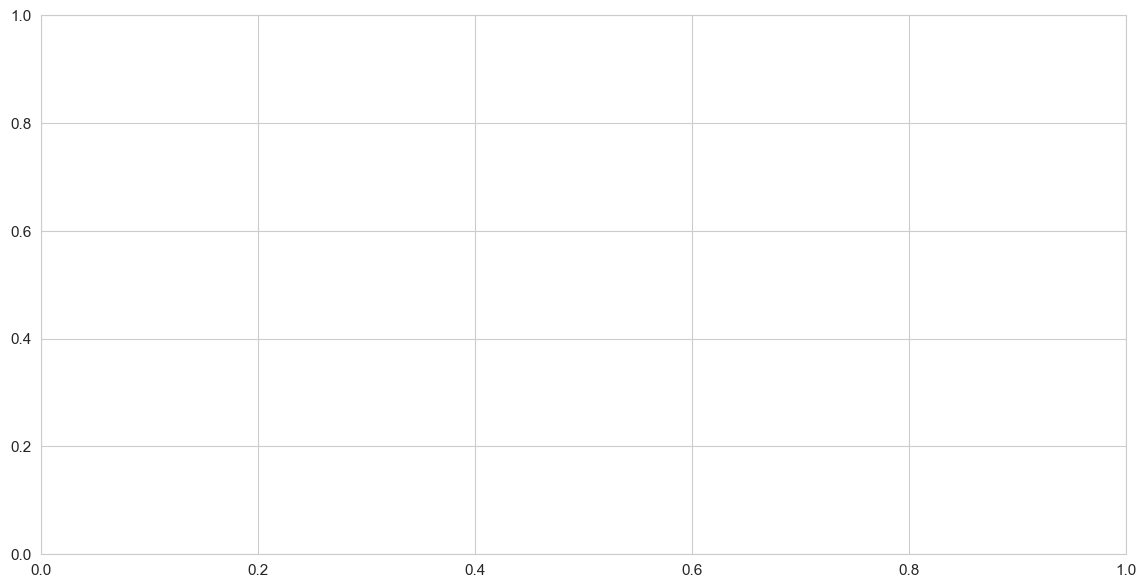

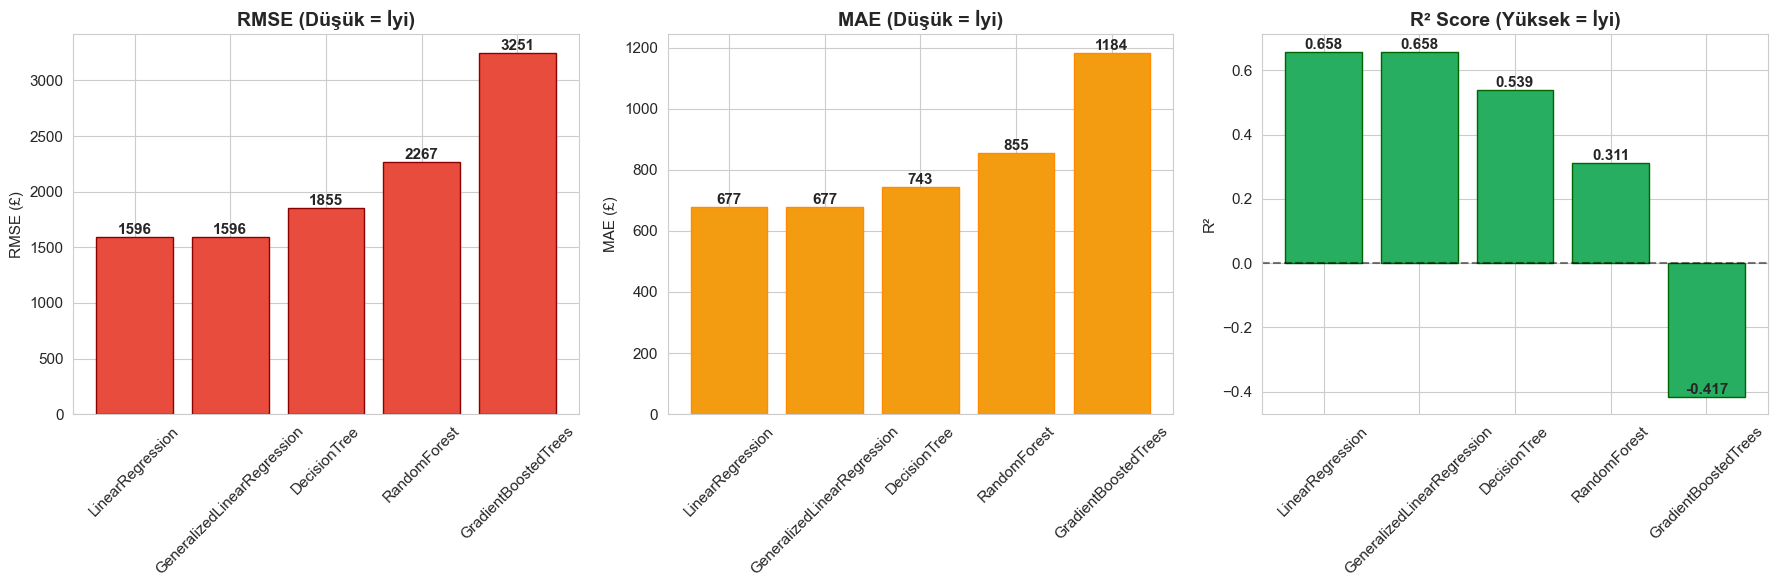

✅ Model karşılaştırma görseli kaydedildi


In [16]:
fig, ax = plt.subplots(figsize=(14, 7))

models = results_df['Model'].tolist()
x = np.arange(len(models))
width = 0.25

# Normalize edilmiş metrikler (RMSE ve MAE büyük, R² küçük — aynı eksende olmaz)
# Bu yüzden 3 ayrı grup için subplot kullanacağız

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RMSE
axes[0].bar(models, results_df['RMSE'], color='#e74c3c', edgecolor='darkred')
axes[0].set_title('RMSE (Düşük = İyi)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE (£)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# MAE
axes[1].bar(models, results_df['MAE'], color='#f39c12', edgecolor='darkorange')
axes[1].set_title('MAE (Düşük = İyi)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE (£)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(results_df['MAE']):
    axes[1].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontweight='bold')

# R²
axes[2].bar(models, results_df['R²'], color='#27ae60', edgecolor='darkgreen')
axes[2].set_title('R² Score (Yüksek = İyi)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
for i, v in enumerate(results_df['R²']):
    axes[2].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/07_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Model karşılaştırma görseli kaydedildi")

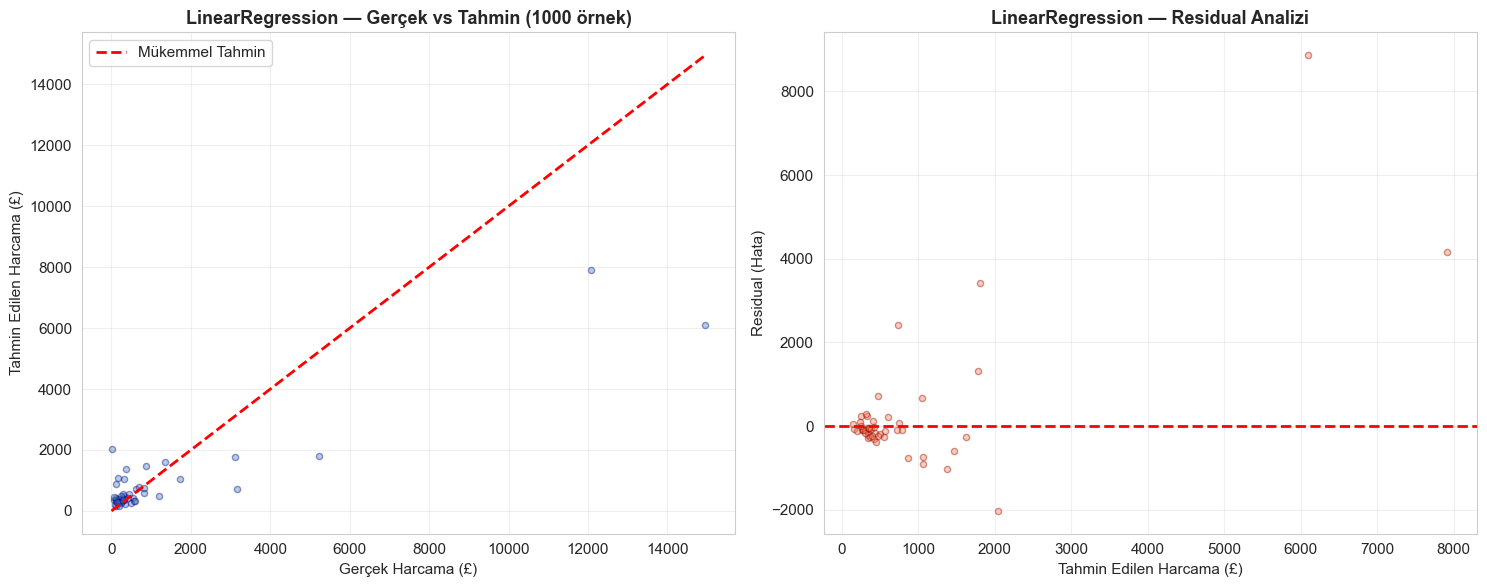


📊 Residual İstatistikleri (LinearRegression):
   Mean residual: £258.48 (ideal: ~0)
   Std residual:  £1591.42
   Max residual:  £8865.94
   Min residual:  £-2027.18


In [17]:
# En iyi modelin tahminlerini al
best_result = [r for r in all_results if r['name'] == best_model_name][0]
best_predictions = best_result['predictions']

# Pandas'a çevir (subset al, hepsi çok büyük olabilir)
pred_pd = best_predictions.select(TARGET_COL, "prediction").limit(1000).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot: Gerçek vs Tahmin
axes[0].scatter(pred_pd[TARGET_COL], pred_pd['prediction'], 
                alpha=0.4, s=20, color='steelblue', edgecolor='darkblue')

# Mükemmel tahmin çizgisi (y=x)
max_val = max(pred_pd[TARGET_COL].max(), pred_pd['prediction'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Mükemmel Tahmin')

axes[0].set_xlabel('Gerçek Harcama (£)')
axes[0].set_ylabel('Tahmin Edilen Harcama (£)')
axes[0].set_title(f'{best_model_name} — Gerçek vs Tahmin (1000 örnek)', 
                   fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
pred_pd['residual'] = pred_pd[TARGET_COL] - pred_pd['prediction']
axes[1].scatter(pred_pd['prediction'], pred_pd['residual'],
                alpha=0.4, s=20, color='coral', edgecolor='darkred')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Tahmin Edilen Harcama (£)')
axes[1].set_ylabel('Residual (Hata)')
axes[1].set_title(f'{best_model_name} — Residual Analizi', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/images/07_best_model_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

# Residual istatistikleri
print(f"\n📊 Residual İstatistikleri ({best_model_name}):")
print(f"   Mean residual: £{pred_pd['residual'].mean():.2f} (ideal: ~0)")
print(f"   Std residual:  £{pred_pd['residual'].std():.2f}")
print(f"   Max residual:  £{pred_pd['residual'].max():.2f}")
print(f"   Min residual:  £{pred_pd['residual'].min():.2f}")

## 5. Feature Importance Analizi

Hocanın istediği zorunlu görsel: **"Feature Importance grafiği (horizontal bar chart)"**

Random Forest ve GBT modellerinden feature importance alıyoruz. Bu sayede **hangi feature'ların ML modeli için en değerli** olduğunu öğreniyoruz.

In [18]:
# Random Forest modelinden feature importance
rf_model = result_rf['model']
gbt_model = result_gbt['model']

# Feature isimlerini al (assembler'dan)
feature_names = assembler.getInputCols()

# Sayısal feature isimleri direkt, kategorik için one-hot vektör elementleri için açıkça yaz
# Bu basit sürüm: vector'ün boyutu kadar feature
rf_importances = rf_model.featureImportances.toArray()
gbt_importances = gbt_model.featureImportances.toArray()

# Eğer numeric_cols ile feature_importance uzunluğu uyuşmuyorsa (kategorik genişlemesi nedeniyle),
# sadece numeric_cols'a karşılık gelen kısmı alalım
n_numeric = len(numeric_cols)

rf_imp_dict = {}
gbt_imp_dict = {}

# Sayısal feature'lar (ilk n_numeric eleman)
for i, name in enumerate(numeric_cols):
    rf_imp_dict[name] = rf_importances[i]
    gbt_imp_dict[name] = gbt_importances[i]

# Kategorik feature (country) — bir bütün olarak topla
if len(rf_importances) > n_numeric:
    rf_imp_dict["country"] = rf_importances[n_numeric:].sum()
if len(gbt_importances) > n_numeric:
    gbt_imp_dict["country"] = gbt_importances[n_numeric:].sum()

# DataFrame'e çevir
rf_imp_df = pd.DataFrame({
    'feature': list(rf_imp_dict.keys()),
    'importance': list(rf_imp_dict.values())
}).sort_values('importance', ascending=True)

gbt_imp_df = pd.DataFrame({
    'feature': list(gbt_imp_dict.keys()),
    'importance': list(gbt_imp_dict.values())
}).sort_values('importance', ascending=True)

print("📊 Random Forest Feature Importance:")
print(rf_imp_df.sort_values('importance', ascending=False))
print("\n📊 GBT Feature Importance:")
print(gbt_imp_df.sort_values('importance', ascending=False))

📊 Random Forest Feature Importance:
                      feature  importance
3            avg_basket_value    0.290948
2                    monetary    0.241916
9                     country    0.093730
6          cancellation_count    0.086607
5             unique_products    0.070416
1                   frequency    0.069315
8            most_active_hour    0.061060
0                recency_days    0.041137
4  avg_days_between_purchases    0.038429
7               active_months    0.006441

📊 GBT Feature Importance:
                      feature  importance
9                     country    0.415453
6          cancellation_count    0.130058
2                    monetary    0.114432
0                recency_days    0.074060
5             unique_products    0.066310
8            most_active_hour    0.061396
1                   frequency    0.053095
3            avg_basket_value    0.047192
4  avg_days_between_purchases    0.037360
7               active_months    0.000644


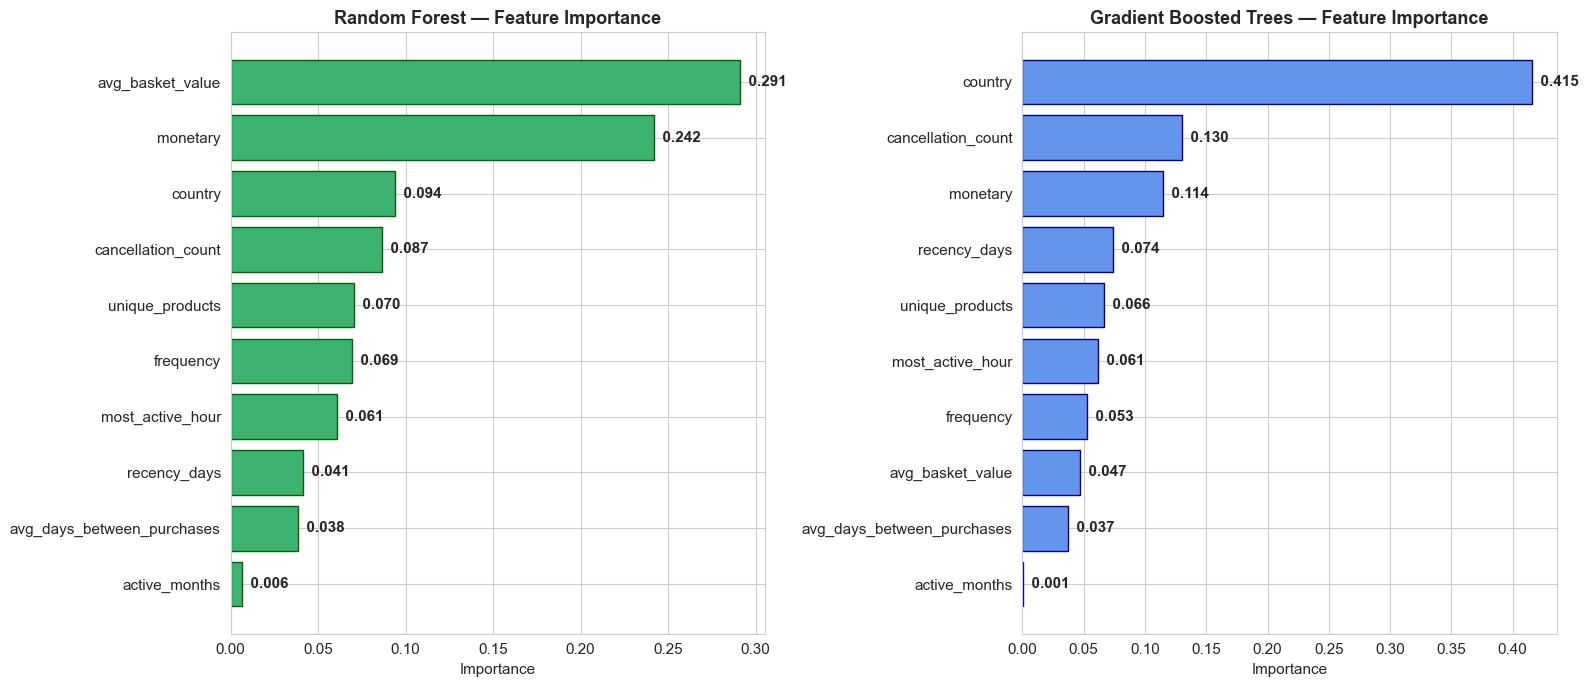


🏆 Random Forest — Top 3 Feature:
   avg_basket_value: 0.2909
   monetary: 0.2419
   country: 0.0937

🏆 GBT — Top 3 Feature:
   country: 0.4155
   cancellation_count: 0.1301
   monetary: 0.1144


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
axes[0].barh(rf_imp_df['feature'], rf_imp_df['importance'],
             color='mediumseagreen', edgecolor='darkgreen')
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
for i, v in enumerate(rf_imp_df['importance']):
    axes[0].text(v, i, f'  {v:.3f}', va='center', fontweight='bold')

# GBT
axes[1].barh(gbt_imp_df['feature'], gbt_imp_df['importance'],
             color='cornflowerblue', edgecolor='darkblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Gradient Boosted Trees — Feature Importance', fontsize=13, fontweight='bold')
for i, v in enumerate(gbt_imp_df['importance']):
    axes[1].text(v, i, f'  {v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/images/07_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# Top 3 feature
top_rf = rf_imp_df.sort_values('importance', ascending=False).head(3)
print(f"\n🏆 Random Forest — Top 3 Feature:")
for _, row in top_rf.iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

top_gbt = gbt_imp_df.sort_values('importance', ascending=False).head(3)
print(f"\n🏆 GBT — Top 3 Feature:")
for _, row in top_gbt.iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# Feature importance'ı MLflow'a logla
with mlflow.start_run(run_name="feature_importance_summary"):
    for feature, imp in zip(rf_imp_df['feature'], rf_imp_df['importance']):
        mlflow.log_metric(f"rf_importance_{feature}", float(imp))
    for feature, imp in zip(gbt_imp_df['feature'], gbt_imp_df['importance']):
        mlflow.log_metric(f"gbt_importance_{feature}", float(imp))

In [20]:
print("=" * 80)
print("📋 FAZ 7 ÖZETİ")
print("=" * 80)
print(f"\n✅ 5 model eğitildi ve MLflow'a kaydedildi:")
for r in all_results:
    print(f"   - {r['name']}: RMSE={r['metrics']['rmse']:.2f}, R²={r['metrics']['r2']:.4f}")

print(f"\n🏆 En iyi model: {best_model_name}")
print(f"   RMSE: {results_df.loc[best_idx, 'RMSE']:.2f}")
print(f"   MAE:  {results_df.loc[best_idx, 'MAE']:.2f}")
print(f"   R²:   {results_df.loc[best_idx, 'R²']:.4f}")

print(f"\n📊 MLflow UI: http://localhost:5001/#/experiments/{experiment.experiment_id}")
print(f"   Toplam run sayısı: 6 (5 model + 1 feature_importance)")

print(f"\n📂 Üretilen görseller:")
for f in ['07_target_dist_before.png', '07_model_comparison.png', 
          '07_best_model_predictions.png', '07_feature_importance.png']:
    print(f"   - docs/images/{f}")

📋 FAZ 7 ÖZETİ

✅ 5 model eğitildi ve MLflow'a kaydedildi:
   - LinearRegression: RMSE=1596.17, R²=0.6584
   - DecisionTree: RMSE=1855.17, R²=0.5385
   - RandomForest: RMSE=2267.06, R²=0.3109
   - GradientBoostedTrees: RMSE=3250.59, R²=-0.4168
   - GeneralizedLinearRegression: RMSE=1596.17, R²=0.6584

🏆 En iyi model: LinearRegression
   RMSE: 1596.17
   MAE:  676.89
   R²:   0.6584

📊 MLflow UI: http://localhost:5001/#/experiments/651823729774552597
   Toplam run sayısı: 6 (5 model + 1 feature_importance)

📂 Üretilen görseller:
   - docs/images/07_target_dist_before.png
   - docs/images/07_model_comparison.png
   - docs/images/07_best_model_predictions.png
   - docs/images/07_feature_importance.png


In [21]:
spark.stop()
print("✅ Spark Session kapatıldı, Faz 7 tamamlandı")

✅ Spark Session kapatıldı, Faz 7 tamamlandı
